# Logistic Regression From Scratch - MNIST Phase 1

Target digit vs all other digits. Target digit -> Class 1. All other digits -> Class 2 for final display. Internally logistic regression uses 1 and 0. Keep this notebook in the same folder as `preprocessing.py`.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from preprocessing import preprocess_mnist


## 1. Experiment settings
Change `method` to `flatten`, `pca`, or `hog`.


In [14]:
target_digit = 0
method = "flatten"      # "flatten", "pca", or "hog"
pca_components = 100

learning_rate = 0.05
epochs = 300


## 2. Load and preprocess data
This creates training, validation, and test sets.


In [15]:
X_train, y_train, X_val, y_val, X_test, y_test = preprocess_mnist(
    target_digit=target_digit,
    method=method,
    pca_components=pca_components
)

print("Method:", method)
print("Target digit:", target_digit)
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nTraining class distribution:")
print("Class 1 target digit:", np.sum(y_train == 1))
print("Class 2 other digits:", np.sum(y_train == 0))


Method: flatten
Target digit: 0
X_train: (51000, 784)
X_val:   (9000, 784)
X_test:  (10000, 784)

Training class distribution:
Class 1 target digit: 5032
Class 2 other digits: 45968


## 3. Logistic regression functions

Model: `z = XW + b`, then `y_hat = sigmoid(z)`.

Loss: binary cross entropy.


In [16]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def compute_loss(y_true, y_pred):
    epsilon = 1e-8
    return -np.mean(
        y_true * np.log(y_pred + epsilon) +
        (1 - y_true) * np.log(1 - y_pred + epsilon)
    )


def predict_probability(X, W, b):
    z = np.dot(X, W) + b
    return sigmoid(z)


def predict_binary(X, W, b):
    probabilities = predict_probability(X, W, b)
    return np.where(probabilities >= 0.5, 1, 0)


def convert_to_class_1_class_2(predictions):
    return np.where(predictions == 1, 1, 2)


## 4. Train model
Training data updates weights. Validation data checks progress and saves the best validation weights.


In [17]:
m, n = X_train.shape

W = np.zeros(n)
b = 0.0

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_W = W.copy()
best_b = b
best_epoch = 0

for epoch in range(epochs):
    y_pred = predict_probability(X_train, W, b)
    train_loss = compute_loss(y_train, y_pred)

    error = y_pred - y_train
    dW = (1 / m) * np.dot(X_train.T, error)
    db = (1 / m) * np.sum(error)

    W = W - learning_rate * dW
    b = b - learning_rate * db

    val_pred = predict_probability(X_val, W, b)
    val_loss = compute_loss(y_val, val_pred)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_W = W.copy()
        best_b = b
        best_epoch = epoch

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

W = best_W
b = best_b

print("\nTraining finished.")
print("Best validation epoch:", best_epoch)
print("Best validation loss:", round(best_val_loss, 4))


Epoch 000 | Train Loss: 0.6931 | Val Loss: 0.6190
Epoch 020 | Train Loss: 0.4128 | Val Loss: 0.4077
Epoch 040 | Train Loss: 0.3316 | Val Loss: 0.3293
Epoch 060 | Train Loss: 0.2791 | Val Loss: 0.2780
Epoch 080 | Train Loss: 0.2414 | Val Loss: 0.2409
Epoch 100 | Train Loss: 0.2130 | Val Loss: 0.2129
Epoch 120 | Train Loss: 0.1908 | Val Loss: 0.1910
Epoch 140 | Train Loss: 0.1732 | Val Loss: 0.1736
Epoch 160 | Train Loss: 0.1588 | Val Loss: 0.1594
Epoch 180 | Train Loss: 0.1470 | Val Loss: 0.1477
Epoch 200 | Train Loss: 0.1371 | Val Loss: 0.1379
Epoch 220 | Train Loss: 0.1286 | Val Loss: 0.1296
Epoch 240 | Train Loss: 0.1214 | Val Loss: 0.1225
Epoch 260 | Train Loss: 0.1151 | Val Loss: 0.1163
Epoch 280 | Train Loss: 0.1096 | Val Loss: 0.1109

Training finished.
Best validation epoch: 299
Best validation loss: 0.1063


## 5. Plot loss curve


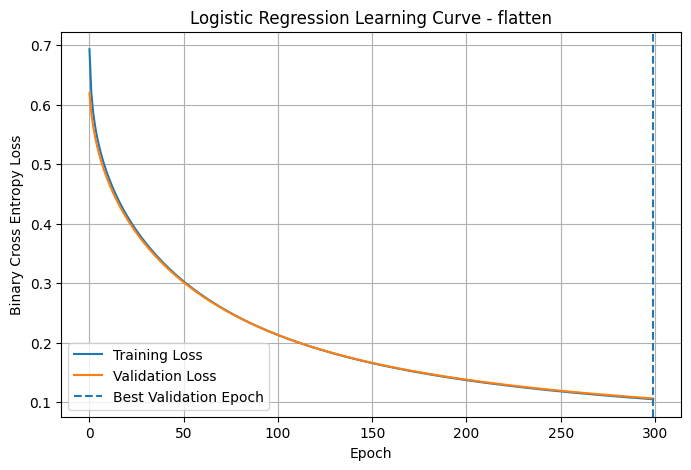

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.axvline(best_epoch, linestyle="--", label="Best Validation Epoch")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Logistic Regression Learning Curve - " + method)
plt.legend()
plt.grid(True)
plt.show()


## 6. Evaluation function


In [19]:
def evaluate(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1_score = 2 * precision * recall / (precision + recall + 1e-8)

    return accuracy, precision, recall, f1_score, TP, TN, FP, FN


## 7. Final test evaluation
This uses the test set only after training is finished.


In [20]:
y_test_pred = predict_binary(X_test, W, b)

accuracy, precision, recall, f1, TP, TN, FP, FN = evaluate(y_test, y_test_pred)
final_predictions = convert_to_class_1_class_2(y_test_pred)

print("FINAL TEST RESULTS")
print("==================")
print("Target digit:", target_digit)
print("Class 1 = digit", target_digit)
print("Class 2 = all other digits")
print("Feature method:", method)
print("Best validation epoch:", best_epoch)

print("\nAccuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nConfusion Matrix")
print("[[TN, FP],")
print(" [FN, TP]]")
print([[TN, FP], [FN, TP]])

print("\nFirst 20 predictions as Class 1 / Class 2:")
print(final_predictions[:20])


FINAL TEST RESULTS
Target digit: 0
Class 1 = digit 0
Class 2 = all other digits
Feature method: flatten
Best validation epoch: 299

Accuracy : 0.9857
Precision: 0.8982
Recall   : 0.9633
F1 Score : 0.9296

Confusion Matrix
[[TN, FP],
 [FN, TP]]
[[np.int64(8913), np.int64(107)], [np.int64(36), np.int64(944)]]

First 20 predictions as Class 1 / Class 2:
[2 2 2 1 2 2 2 2 2 2 1 2 2 1 2 2 2 2 2 2]


## 8. Result row for report
Run the notebook three times with `flatten`, `pca`, and `hog`, then copy the final results into your report table.


In [21]:
results_row = {
    "target_digit": target_digit,
    "method": method,
    "best_epoch": best_epoch,
    "accuracy": round(float(accuracy), 4),
    "precision": round(float(precision), 4),
    "recall": round(float(recall), 4),
    "f1": round(float(f1), 4),
}

results_row


{'target_digit': 0,
 'method': 'flatten',
 'best_epoch': 299,
 'accuracy': 0.9857,
 'precision': 0.8982,
 'recall': 0.9633,
 'f1': 0.9296}